In [1]:
import pandas as pd
import numpy as np

In [8]:
sf_permits = pd.read_csv("Building_Permits.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_19740\2328691824.py:1: DtypeWarning: Columns (0: Voluntary Soft-Story Retrofit, 1: TIDF Compliance) have mixed types. Specify dtype option on import or set low_memory=False.
  sf_permits = pd.read_csv("Building_Permits.csv")


In [9]:
sf_permits.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,NaN,Ellis,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,NaN,Geary,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,NaN,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,NaN,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,NaN,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,NaN,Market,St,...,3.0,constr type 3,NaN,NaN,NaN,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992


In [ ]:
sf_permits.isna().sum()[0:20]


Permit Number                            0
Permit Type                              0
Permit Type Definition                   0
Permit Creation Date                     0
Block                                    0
Lot                                      0
Street Number                            0
Street Number Suffix                196684
Street Name                              0
Street Suffix                         2768
Unit                                169421
Unit Suffix                         196939
Description                            290
Current Status                           0
Current Status Date                      0
Filed Date                               0
Issued Date                          14940
Completed Date                      101709
First Construction Document Date     14946
Structural Notification             191978
dtype: int64

In [22]:
sf_permits.shape

(198900, 43)

Handling Missing Data

In [30]:
# percentage of the values in our dataset were missing
total_cells = np.prod(sf_permits.shape)
total_missing = sf_permits.isna().sum().sum()

percent_missing = (total_missing / total_cells) * 100
print(f"Total missing cell is {percent_missing:.2f} %")

Total missing cell is 26.26 %


In [31]:
np.random.seed(0)

In [33]:
# remove all columns with at least one missing value
columns_with_na_dropped = sf_permits.dropna(axis = 1)
columns_with_na_dropped.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Current Status,Current Status Date,Filed Date,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,Ellis,expired,12/21/2017,05/06/2015,1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,Geary,issued,08/03/2017,04/19/2016,1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,Pacific,withdrawn,09/26/2017,05/27/2016,1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,Pacific,complete,07/24/2017,11/07/2016,1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,Market,issued,12/01/2017,11/28/2016,144548169992


In [36]:
# just how much data did we lose?
print("Columns in original dataset: %d \n" % sf_permits.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

dropped_columns = sf_permits.shape[1] - columns_with_na_dropped.shape[1]
print(dropped_columns)

Columns in original dataset: 43 

Columns with na's dropped: 12
31


In [ ]:
#replacing all the NaN's in the sf_permits data with the one that comes directly after it and then replacing any remaining NaN's with 0. 
sf_permits_with_na_imputed = sf_permits.bfill(axis=0).fillna(0) 
#bfill- Fill NA/NaN values by using the next valid observation to fill the gap

Scaling and Normalizing

Transforming the values of numeric variables so that the transformed data points have specific helpful properties. The difference is that:

* in scaling, you're changing the range of your data, while
in normalization, you're changing the shape of the distribution of your data.

In [42]:
# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

Scaling
 
 Transforming your data so that it fits within a specific scale, like 0-100 or 0-1. You want to scale data when you're using methods based on measures of how far apart data points are, like support vector machines (SVM) or k-nearest neighbors (KNN). With these algorithms, a change of "1" in any numeric feature is given the same importance.

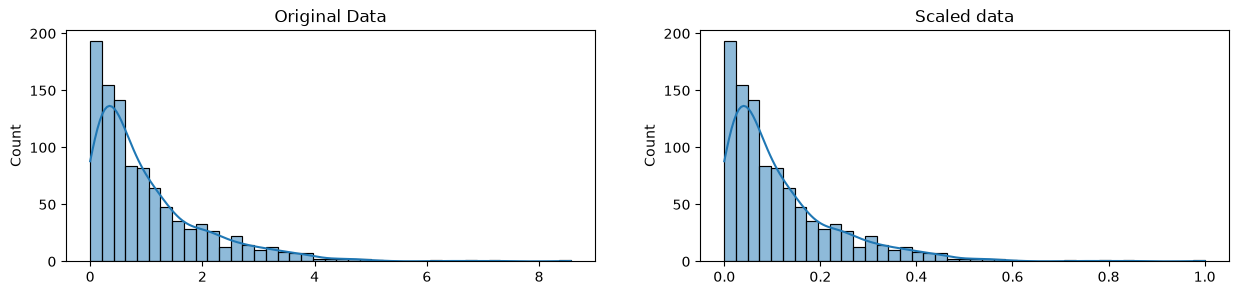

In [43]:
# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0])

# plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Scaled data")
plt.show()

Notice that the shape of the data doesn't change, but that instead of ranging from 0 to 8ish, it now ranges from 0 to 1.

Normalization

The point of normalization is to change your observations so that they can be described as a normal distribution. You'll normalize your data if you're going to be using a machine learning or statistics technique that assumes your data is normally distributed. Some examples of these include linear discriminant analysis (LDA) and Gaussian naive Bayes. 

The method we're using to normalize here is called the Box-Cox Transformation.

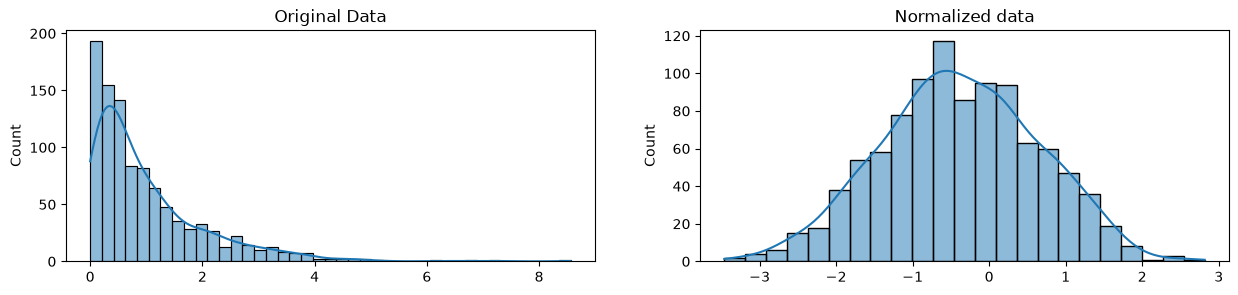

In [44]:
# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# plot both together to compare
fig, ax=plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized data")
plt.show()

Notice that the shape of our data has changed. Before normalizing it was almost L-shaped. But after normalizing it looks more like the outline of a bell (hence "bell curve").

Parsing Data

Parsing dates because we're taking in a string and identifying its component parts.

In [45]:
import datetime

In [49]:
sf_permits["Permit Creation Date"].head()

0    05/06/2015
1    04/19/2016
2    05/27/2016
3    11/07/2016
4    11/28/2016
Name: Permit Creation Date, dtype: str

Converting Date Column to Datetime

In [58]:
date_lengths = sf_permits["Permit Creation Date"].str.len()
date_lengths.value_counts()

Permit Creation Date
10    198900
Name: count, dtype: int64

In [56]:
sf_permits['date_parsed'] = pd.to_datetime(sf_permits['Permit Creation Date'], format="%m/%d/%Y")
sf_permits['date_parsed'].head()

0   2015-05-06
1   2016-04-19
2   2016-05-27
3   2016-11-07
4   2016-11-28
Name: date_parsed, dtype: datetime64[us]

In [61]:
day_of_month_permit = sf_permits['date_parsed'].dt.day
day_of_month_permit.head()
#selecting day of the month

0     6
1    19
2    27
3     7
4    28
Name: date_parsed, dtype: int32

Plot the day of the month to check the date parsing

C:\Users\User\AppData\Local\Temp\ipykernel_19740\3560257269.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(day_of_month_permit, kde=False, bins=31)


<Axes: xlabel='date_parsed'>

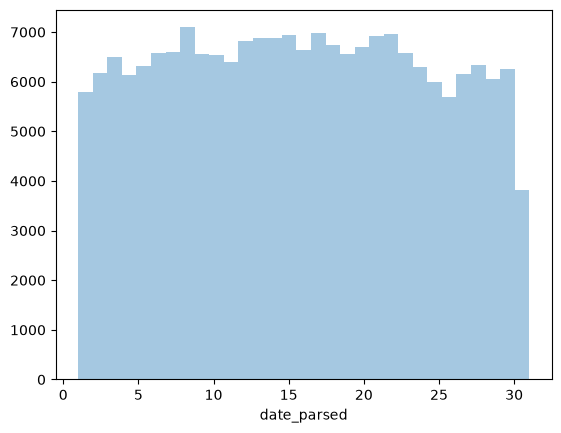

In [62]:
# remove na's
day_of_month_permit = day_of_month_permit.dropna()

# plot the day of the month
sns.distplot(day_of_month_permit, kde=False, bins=31)

Character Encoding

Character encodings are specific sets of rules for mapping from raw binary byte strings (that look like this: 0110100001101001) to characters that make up human-readable text (like "hi"). There are lots of different character encodings, but the main one you need to know is UTF-8.

In [8]:
import fuzzywuzzy
from fuzzywuzzy import process
import charset_normalizer

ModuleNotFoundError: No module named 'fuzzywuzzy'

In [6]:
# start with a string
before = "This is the euro symbol: €"
# check to see what datatype it is
print(type(before))

# encode it to a different encoding, replacing characters that raise errors
after = before.encode("utf-8", errors="replace")
print(after) #bytes are printed out as if they were characters encoded in ASCII. 
# check the type
print(type(after))

<class 'str'>
b'This is the euro symbol: \xe2\x82\xac'
<class 'bytes'>


In [7]:
print(after.decode("utf-8")) #convert our bytes back to a string with the correct encoding

This is the euro symbol: €


Reading in files with encoding problems

In [ ]:
#TODO: Load in the DataFrame correctly. Do not run, just for example code

with open("../input/fatal-police-shootings-in-the-us/PoliceKillingsUS.csv", "rb") as rawdata:
    result = charset_normalizer.detect(rawdata.read(100000))
# check what the character encoding might be
print(result)
# read in the file with the encoding detected by charset_normalizer
police_killings = pd.read_csv("../input/fatal-police-shootings-in-the-us/PoliceKillingsUS.csv", 
                              encoding= "windows-1250")

Saving your files with UTF-8 encoding

In [ ]:
police_killings.to_csv("my_files") #Do Not Run

Inconsistent Data Entry

Do some preliminary text pre-processing

"""# get all the unique values in the 'Country' column

countries = professors['Country'].unique()"""

"""# sort them alphabetically and then take a closer look

countries.sort()

countries"""

Use fuzzy matching to correct inconsistent data entry

The fuzzywuzzy package to help identify which strings are closest to each other. 

Fuzzy matching: Process of automatically finding text strings that are very similar to the target string. In general, a string is considered "closer" to another one the fewer characters you'd need to change if you were transforming one string into another. So "apple" and "snapple" are two changes away from each other (add "s" and "n") while "in" and "on" and one change away (rplace "i" with "o"). You won't always be able to rely on fuzzy matching 100%, but it will usually end up saving you at least a little time.

Fuzzywuzzy returns a ratio given two strings. The closer the ratio is to 100, smaller the edit distance between the two strings.

In [ ]:
# get the top 10 closest matches to "south korea". Do not run, just example code
matches = fuzzywuzzy.process.extract(
    "south korea", countries, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio
    )

In [ ]:
# function to replace rows in the provided column of the provided dataframe "Do not Run"
# that match the provided string above the provided ratio with the provided string
def replace_matches_in_column(df, column, string_to_match, min_ratio = 47):
    # get a list of unique strings
    strings = df[column].unique()
    
    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings, 
                                         limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

    # only get matches with a ratio > 90
    close_matches = [matches[0] for matches in matches if matches[1] >= min_ratio]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches 
    df.loc[rows_with_matches, column] = string_to_match
    
    # let us know the function's done
    print("All done!")